In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

%matplotlib inline

In [3]:
DATA_PATH = (
    "../data/features/"
    "nifty50_features.csv"
)

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["Date"],
)

df.head()

,Date,Open,High,Low,Close,Volume,return,log_return,volatility_20d,rsi_14,macd,macd_signal,macd_histogram,atr_14,volume_change,volume_ma_20
0,2022-02-01,17529.449219,17622.400391,17244.550781,17576.849609,386400,0.013668,0.013575,0.010512,60.680331,-117.236885,-45.520134,-71.716751,290.674486,0.201119,281070.0
1,2022-02-02,17706.199219,17794.599609,17674.800781,17780.000000,271200,0.011558,0.011492,0.010586,64.074128,-88.394175,-54.094942,-34.299233,285.465594,-0.298137,282260.0
2,2022-02-03,17767.750000,17781.150391,17511.150391,17560.199219,226600,-0.012362,-0.012439,0.010804,58.218993,-82.323235,-59.740601,-22.582634,284.360909,-0.164454,281015.0
3,2022-02-04,17590.199219,17617.800781,17462.550781,17516.300781,261400,-0.002500,-0.002503,0.010602,57.096792,-80.130513,-63.818583,-16.311930,275.138701,0.153575,282260.0
4,2022-02-07,17456.300781,17536.750000,17119.400391,17213.599609,265000,-0.017281,-0.017432,0.011181,49.947410,-101.646503,-71.384167,-30.262336,285.296623,0.013772,283545.0


In [4]:
feature_columns = [
    "return",
    "log_return",
    "volatility_20d",
    "rsi_14",
    "macd",
    "macd_signal",
    "macd_histogram",
    "atr_14",
    "volume_change",
    "volume_ma_20",
]

features = df[feature_columns]

features.head()

,return,log_return,volatility_20d,rsi_14,macd,macd_signal,macd_histogram,atr_14,volume_change,volume_ma_20
0,0.013668,0.013575,0.010512,60.680331,-117.236885,-45.520134,-71.716751,290.674486,0.201119,281070.0
1,0.011558,0.011492,0.010586,64.074128,-88.394175,-54.094942,-34.299233,285.465594,-0.298137,282260.0
2,-0.012362,-0.012439,0.010804,58.218993,-82.323235,-59.740601,-22.582634,284.360909,-0.164454,281015.0
3,-0.002500,-0.002503,0.010602,57.096792,-80.130513,-63.818583,-16.311930,275.138701,0.153575,282260.0
4,-0.017281,-0.017432,0.011181,49.947410,-101.646503,-71.384167,-30.262336,285.296623,0.013772,283545.0


In [5]:
correlation_matrix = features.corr()

correlation_matrix

,return,log_return,volatility_20d,rsi_14,macd,macd_signal,macd_histogram,atr_14,volume_change,volume_ma_20
return,1.000000,0.999942,0.030024,0.330969,0.046807,-0.011418,0.180579,0.005774,-0.091708,0.012465
log_return,0.999942,1.000000,0.026594,0.332217,0.048556,-0.009876,0.181546,0.002451,-0.092534,0.011094
volatility_20d,0.030024,0.026594,1.000000,-0.188364,-0.274008,-0.337518,0.130352,0.792945,-0.036460,0.514751
rsi_14,0.330969,0.332217,-0.188364,1.000000,0.813163,0.656949,0.625403,-0.335061,-0.008116,-0.101178
macd,0.046807,0.048556,-0.274008,0.813163,1.000000,0.948081,0.357418,-0.403827,0.012763,-0.123824
macd_signal,-0.011418,-0.009876,-0.337518,0.656949,0.948081,1.000000,0.041839,-0.435397,0.010186,-0.170469
macd_histogram,0.180579,0.181546,0.130352,0.625403,0.357418,0.041839,1.000000,0.009945,0.010185,0.111603
atr_14,0.005774,0.002451,0.792945,-0.335061,-0.403827,-0.435397,0.009945,1.000000,-0.017822,0.760641
volume_change,-0.091708,-0.092534,-0.036460,-0.008116,0.012763,0.010186,0.010185,-0.017822,1.000000,-0.028468
volume_ma_20,0.012465,0.011094,0.514751,-0.101178,-0.123824,-0.170469,0.111603,0.760641,-0.028468,1.000000


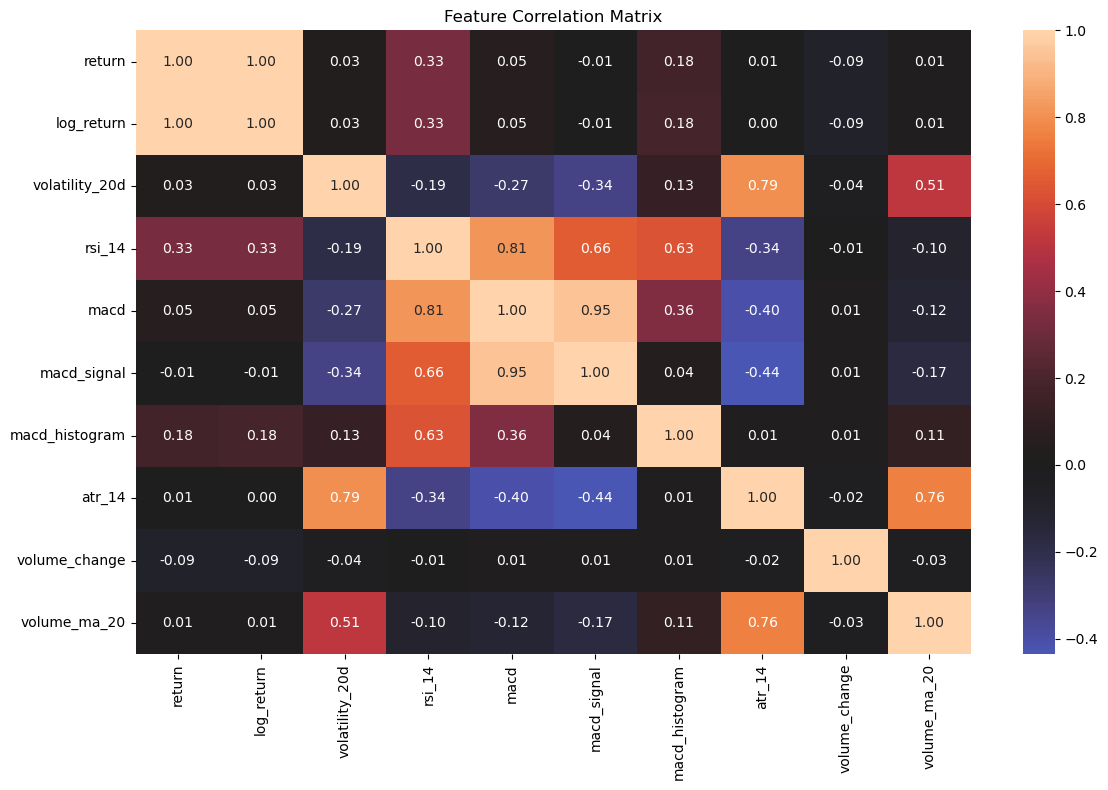

In [6]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [7]:
features.describe().T

,count,mean,std,min,25%,50%,75%,max
return,1110.0,0.000345,0.008706,-0.059294,-0.004146,0.000428,0.005304,0.038183
log_return,1110.0,0.000307,0.008718,-0.061124,-0.004155,0.000428,0.005290,0.037472
volatility_20d,1110.0,0.008126,0.003323,0.003161,0.005821,0.007278,0.009370,0.019047
rsi_14,1110.0,53.423134,12.094756,21.788395,44.527750,53.556848,61.820186,85.256264
macd,1110.0,39.547114,189.926942,-662.927251,-85.865293,56.206256,168.767321,451.083428
macd_signal,1110.0,39.263136,177.536678,-614.943938,-84.523843,51.803532,164.218122,413.985339
macd_histogram,1110.0,0.283979,60.455316,-193.013144,-41.710485,-3.222406,41.140338,230.579215
atr_14,1110.0,237.207994,64.839311,128.208300,192.560402,230.662389,275.634351,496.312895
volume_change,1110.0,0.058431,0.603207,-1.000000,-0.138914,-0.004739,0.155646,12.094421
volume_ma_20,1110.0,308324.792793,63180.788799,201250.000000,266841.250000,290505.000000,334007.500000,525685.000000


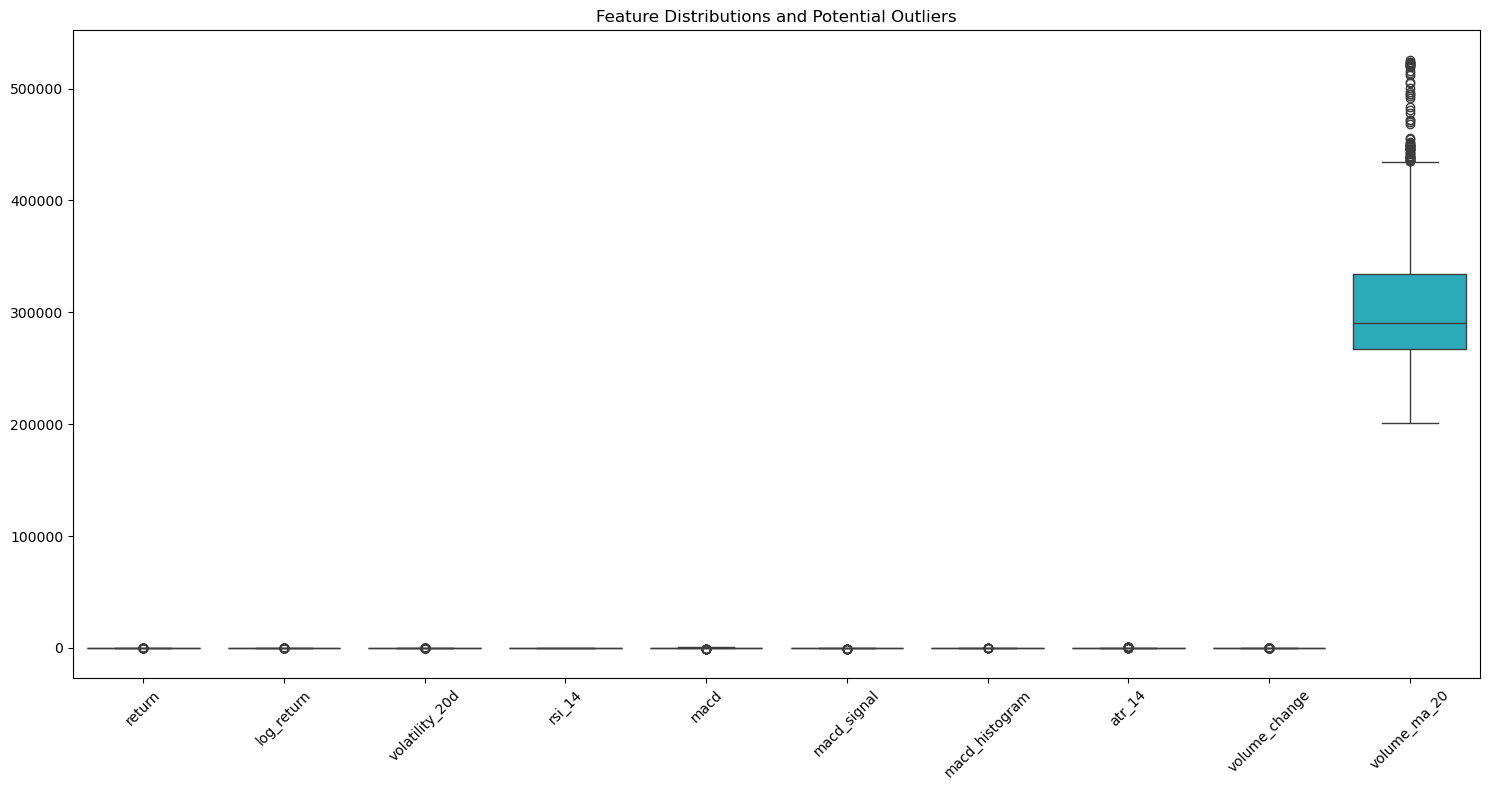

In [8]:
plt.figure(figsize=(15, 8))

sns.boxplot(data=features)

plt.title("Feature Distributions and Potential Outliers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Feature Skewness'}>

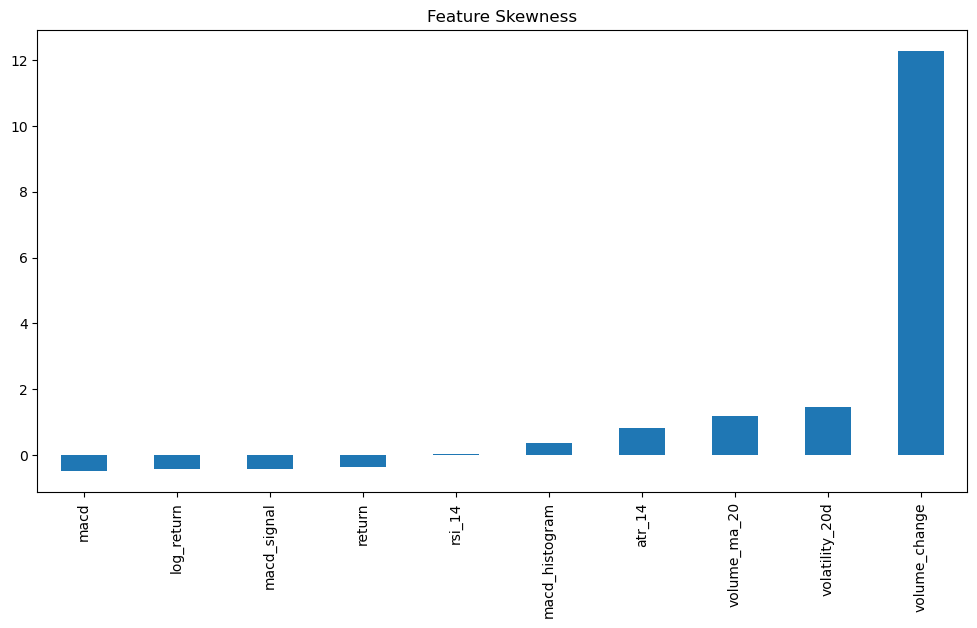

In [11]:
features.skew().sort_values().plot(kind="bar", figsize=(12, 6), title="Feature Skewness")

In [12]:
features.skew().sort_values()

macd              -0.495032
log_return        -0.439611
macd_signal       -0.434682
return            -0.360357
rsi_14             0.022929
macd_histogram     0.348203
atr_14             0.830666
volume_ma_20       1.186977
volatility_20d     1.443099
volume_change     12.274429
dtype: float64

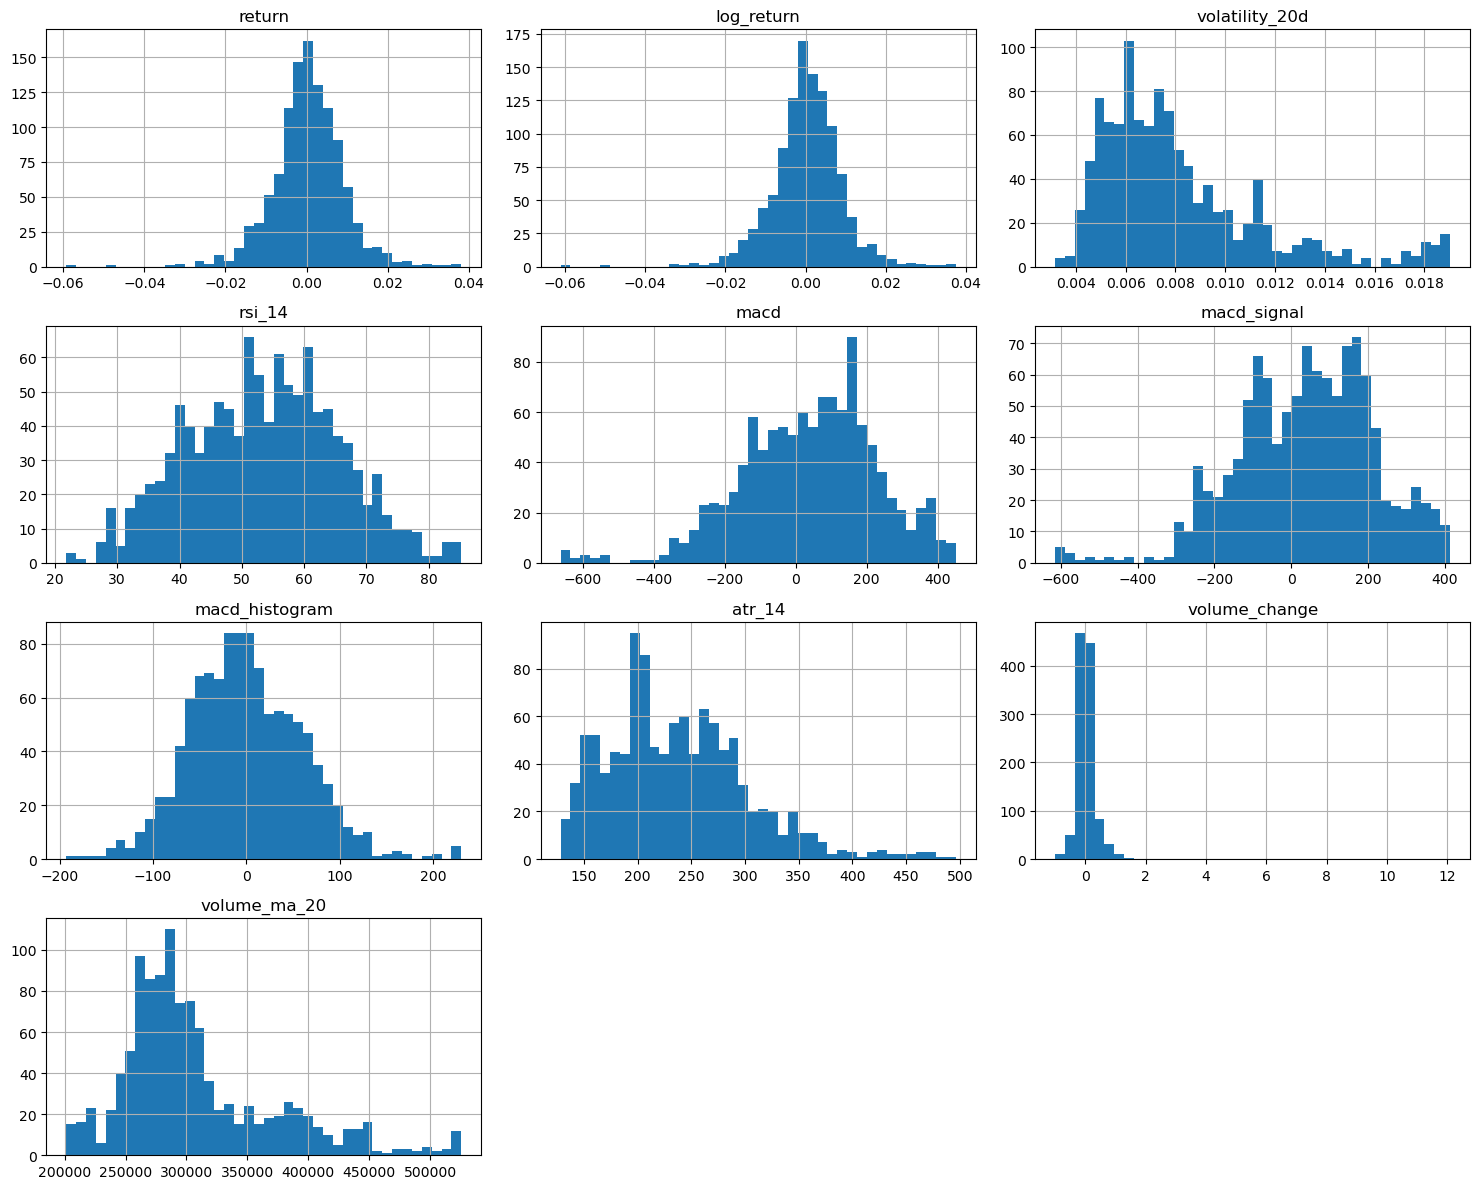

In [13]:
features.hist(
    figsize=(15, 12),
    bins=40
)

plt.tight_layout()
plt.show()